# 01 Data Ingestion & EDA
This notebook focuses on loading the pneumonia dataset from the local `artifacts` folder and performing basic Exploratory Data Analysis (EDA).

In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

# Define data paths (using the provided artifacts)
data_dir = r'j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

print(f"Data Directory: {data_dir}")
print(f"Train Directory: {train_dir}")
print(f"Test Directory: {test_dir}")

Data Directory: j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data
Train Directory: j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data\train
Test Directory: j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data\test


## Class Distribution

Train counts: {'NORMAL': 105, 'PNEUMONIA': 105}
Test counts: {'NORMAL': 27, 'PNEUMONIA': 30}


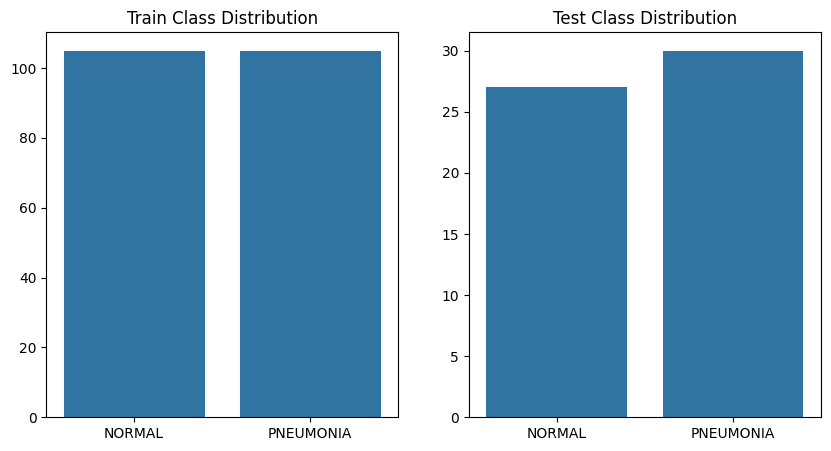

In [4]:
def count_files(directory):
    classes = ['NORMAL', 'PNEUMONIA']
    counts = {}
    for cls in classes:
        path = os.path.join(directory, cls)
        counts[cls] = len(os.listdir(path))
    return counts

train_counts = count_files(train_dir)
test_counts = count_files(test_dir)

print(f"Train counts: {train_counts}")
print(f"Test counts: {test_counts}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()))
plt.title('Train Class Distribution')

plt.subplot(1, 2, 2)
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()))
plt.title('Test Class Distribution')
plt.show()

## Visualize Samples

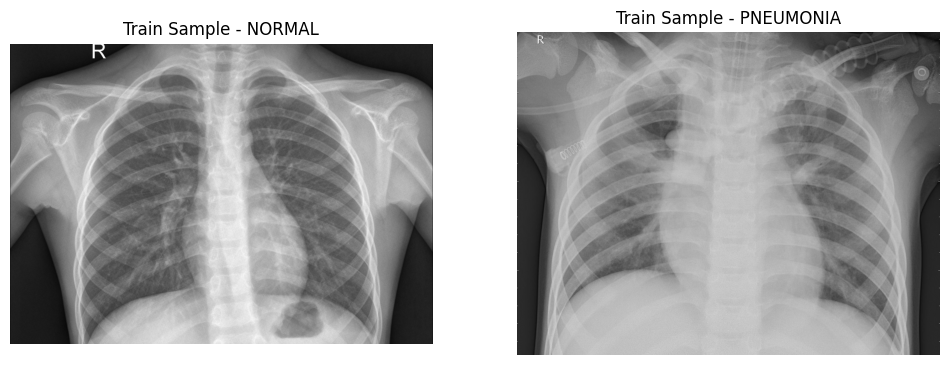

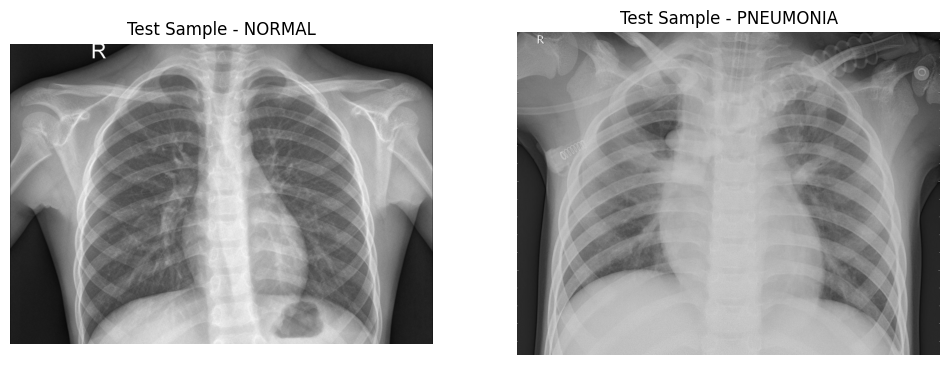

In [5]:
def show_samples(directory, title):
    classes = ['NORMAL', 'PNEUMONIA']
    plt.figure(figsize=(12, 6))
    for i, cls in enumerate(classes):
        path = os.path.join(directory, cls)
        img_name = os.listdir(path)[0]
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)
        
        plt.subplot(1, 2, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{title} - {cls}")
        plt.axis('off')
    plt.show()

show_samples(train_dir, 'Train Sample')
show_samples(test_dir, 'Test Sample')